In [1]:
import torch
from transformers.tokenization_utils_base import BatchEncoding

# Use safe_globals context manager
with torch.serialization.safe_globals([BatchEncoding]):
    tokens = torch.load("../work/2c/f6e81982e2332dc14774fc99ed6563/tokens.pt", map_location="cpu")

print(tokens)

# Use safe_globals context manager
with torch.serialization.safe_globals([BatchEncoding]):
    embeddings = torch.load("../work/54/1218ddfcc03da6cfcd1c4d4dc680c2/embeddings.pt", map_location="cpu")

print(embeddings)

/home/sridhara-omics/Github_repos/ProteinLMs/lms/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'input_ids': tensor([[ 0,  6,  4,  ...,  1,  1,  1],
        [ 0, 11,  4,  ...,  1,  1,  1],
        [ 0,  8,  4,  ...,  1,  1,  1],
        ...,
        [ 0,  8,  4,  ...,  1,  1,  1],
        [ 0,  8,  4,  ...,  1,  1,  1],
        [ 0, 16,  4,  ...,  2,  1,  1]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 0, 0]])}
tensor([[[-0.1536,  0.7431,  0.0862,  ...,  0.8601,  0.0117, -0.3462],
         [ 0.0279,  0.0764, -0.1199,  ...,  0.4948, -0.0456, -0.2456],
         [-0.5646,  0.1197, -0.2543,  ...,  0.6811,  0.0683,  0.2055],
         ...,
         [-0.3476,  0.3924,  0.0624,  ...,  0.4059, -0.3123,  0.0457],
         [-0.3546,  0.3246, -0.2944,  ...,  0.1670, -0.4913, -0.0380],
         [-0.4176,  0.3403, -0.2839,  ..., -0.0012, -0.3930, -0.0176]],

        [[-0.3656,  0.5796, -0.1875,  ...,  0.6213, 

In [2]:
# Print type and shape
print(type(tokens), getattr(tokens, 'shape', 'no shape'))
print(type(embeddings), getattr(embeddings, 'shape', 'no shape'))

# Peek at the first few elements
print(tokens[:10])
print(embeddings[:5])

<class 'transformers.tokenization_utils_base.BatchEncoding'> no shape
<class 'torch.Tensor'> torch.Size([1022, 100, 320])
{'input_ids': tensor([[ 0,  6,  4,  7, 15, 14,  8,  9, 11,  4,  8,  4, 11, 23, 11,  4,  8,  6,
          6,  8, 12,  6,  8, 21, 18, 10, 23, 22,  7, 10, 16, 14, 14,  6, 10, 10,
          4,  9, 22, 12, 23, 22, 19, 19, 19, 13,  6, 17, 11, 19, 19, 17, 14,  8,
          4, 10,  8, 14,  7,  5, 12, 14,  7, 13, 11,  8, 15, 17, 16,  4,  8,  4,
         11,  4,  8,  8,  7, 11,  5,  8, 13, 11,  5,  7, 19,  8, 23,  5,  2,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 0, 11,  4,  8,  4, 11, 23, 11,  4, 14,  6,  6,  8, 12,  6,  8, 21, 18,
         22, 23, 22, 12, 10, 16, 14, 14,  6, 10,  6,  4,  9, 22, 12,  6, 23, 19,
         19, 19,  8,  6,  8, 11, 19, 19, 17, 14,  8,  4, 15,  8, 14,  7,  5, 12,
          8, 11, 13, 11,  8, 15, 17, 16, 18,  8,  4, 10,  4,  8,  8,  7, 11,  5,
         11, 13, 11,  5,  7, 19, 19, 23,  5,  2,  1,  1,  1,  1,  1,  1,  1,  1,
    

In [4]:
tokens_np = tokens.numpy() if torch.is_tensor(tokens) else tokens
embeddings_np = embeddings.numpy() if torch.is_tensor(embeddings) else embeddings

print(tokens_np[:10])
print(embeddings_np[:5])

{'input_ids': tensor([[ 0,  6,  4,  7, 15, 14,  8,  9, 11,  4,  8,  4, 11, 23, 11,  4,  8,  6,
          6,  8, 12,  6,  8, 21, 18, 10, 23, 22,  7, 10, 16, 14, 14,  6, 10, 10,
          4,  9, 22, 12, 23, 22, 19, 19, 19, 13,  6, 17, 11, 19, 19, 17, 14,  8,
          4, 10,  8, 14,  7,  5, 12, 14,  7, 13, 11,  8, 15, 17, 16,  4,  8,  4,
         11,  4,  8,  8,  7, 11,  5,  8, 13, 11,  5,  7, 19,  8, 23,  5,  2,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 0, 11,  4,  8,  4, 11, 23, 11,  4, 14,  6,  6,  8, 12,  6,  8, 21, 18,
         22, 23, 22, 12, 10, 16, 14, 14,  6, 10,  6,  4,  9, 22, 12,  6, 23, 19,
         19, 19,  8,  6,  8, 11, 19, 19, 17, 14,  8,  4, 15,  8, 14,  7,  5, 12,
          8, 11, 13, 11,  8, 15, 17, 16, 18,  8,  4, 10,  4,  8,  8,  7, 11,  5,
         11, 13, 11,  5,  7, 19, 19, 23,  5,  2,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 0,  8,  4, 10,  4,  8, 23,  5,  5,  8,  6, 18,  8, 18,  6, 10, 19,

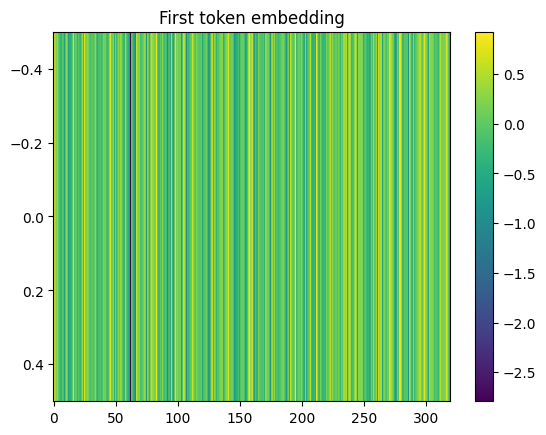

In [5]:
import matplotlib.pyplot as plt

# Pick first sequence, first token
token_embedding = embeddings_np[0, 0, :].reshape(1, -1)  # shape (1, 320)
plt.imshow(token_embedding, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("First token embedding")
plt.show()

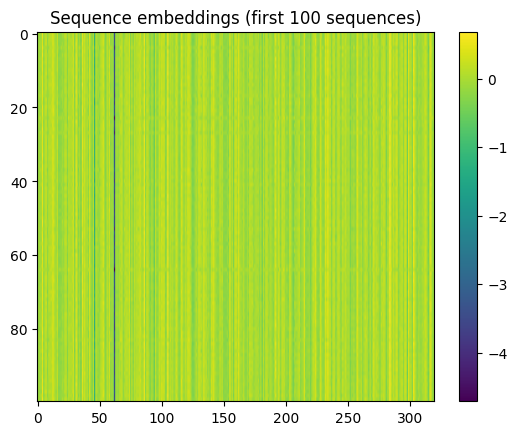

In [6]:
seq_embeddings = embeddings_np.mean(axis=1)  # shape: (num_sequences, embedding_dim)
plt.imshow(seq_embeddings[:100, :], aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Sequence embeddings (first 100 sequences)")
plt.show()

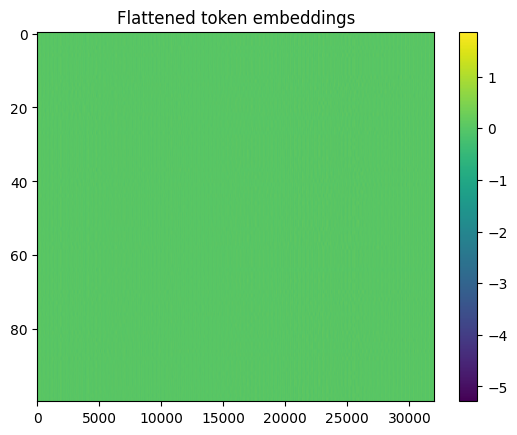

In [7]:
flattened = embeddings_np[:100].reshape(100, -1)  # shape: (100, 50*320)
plt.imshow(flattened, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Flattened token embeddings")
plt.show()